In [19]:
import os
import pandas as pd
from dotenv import load_dotenv
from gsheet_loader import load_sheet

load_dotenv()

# Load a Google Sheet URL from .env
url = os.getenv("GOOGLE_SHEET_URL")
if not url:
    raise ValueError("GOOGLE_SHEET_URL is not set in .env")

data = load_sheet(url)

In [20]:
df = pd.read_csv(data)

In [21]:
df.drop('submittedAt', axis=1, inplace=True)

In [22]:
df['B5_time_with_parents_hours'] = df['B5_time_with_parents_hours'].str.replace('â', '-', regex=False)
df['D1_daily_screen'] = df['D1_daily_screen'].str.replace('â', '-', regex=False)
df['D2_weekend_screen'] = df['D2_weekend_screen'].str.replace('â', '-', regex=False)
df['D5_parents_screen_time'] = df['D5_parents_screen_time'].str.replace('â', '-', regex=False)
df['E1_sleep_duration'] = df['E1_sleep_duration'].str.replace('â', '-', regex=False)

## **Outlier Detection**

In [23]:
# Inspect raw values to diagnose parsing issue
print("Unique values in B5_time_with_parents_hours:")
print(df['B5_time_with_parents_hours'].unique())

print("\nSample repr (shows hidden characters):")
for v in df['B5_time_with_parents_hours'].dropna().unique()[:10]:
    print(repr(v))


Unique values in B5_time_with_parents_hours:
['2-4 hours' '4-6 hours' '1-2 hours' 'More than 6 hours'
 'Less than 1 hour']

Sample repr (shows hidden characters):
'2-4 hours'
'4-6 hours'
'1-2 hours'
'More than 6 hours'
'Less than 1 hour'


Column: A1_age_years  |  Total valid rows: 452

IQR Method  |  Q1=14.0, Q3=17.0, IQR=3.00
  Bounds: [9.50, 21.50]
  Outliers (0):
  None

Z-Score Method  |  Mean=15.71, Std=1.98
  Outliers (0):
  None


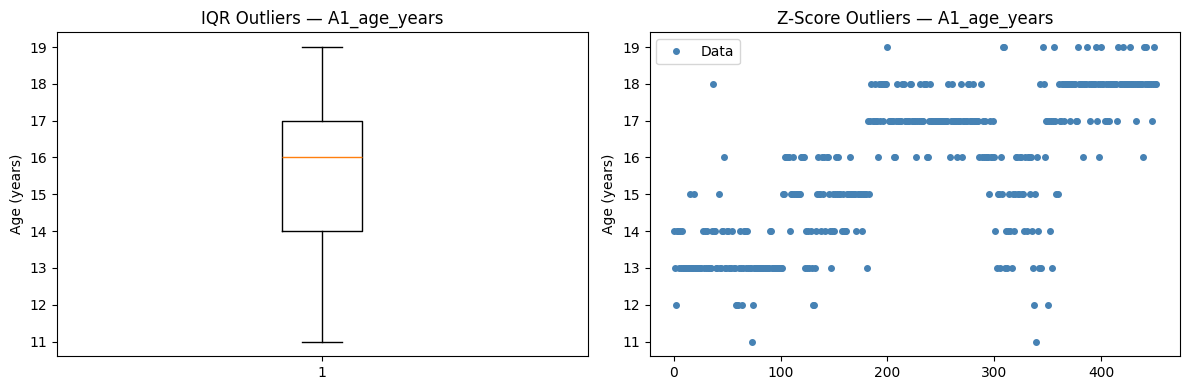

In [24]:
import numpy as np
import matplotlib.pyplot as plt

col = 'A1_age_years'
series = pd.to_numeric(df[col], errors='coerce').dropna()

# --- IQR Method ---
Q1 = series.quantile(0.25)
Q3 = series.quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
iqr_outliers = series[(series < lower_iqr) | (series > upper_iqr)]

# --- Z-Score Method ---
z_scores = (series - series.mean()) / series.std()
z_outliers = series[z_scores.abs() > 3]

print(f"Column: {col}  |  Total valid rows: {len(series)}")
print(f"\nIQR Method  |  Q1={Q1}, Q3={Q3}, IQR={IQR:.2f}")
print(f"  Bounds: [{lower_iqr:.2f}, {upper_iqr:.2f}]")
print(f"  Outliers ({len(iqr_outliers)}):\n{iqr_outliers.to_string() if len(iqr_outliers) else '  None'}")

print(f"\nZ-Score Method  |  Mean={series.mean():.2f}, Std={series.std():.2f}")
print(f"  Outliers ({len(z_outliers)}):\n{z_outliers.to_string() if len(z_outliers) else '  None'}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(series, vert=True)
if len(iqr_outliers):
    axes[0].scatter([1]*len(iqr_outliers), iqr_outliers, color='red', zorder=5, label='Outliers')
    axes[0].legend()
axes[0].set_title(f'IQR Outliers — {col}')
axes[0].set_ylabel('Age (years)')

axes[1].plot(series.values, 'o', color='steelblue', markersize=4, label='Data')
if len(z_outliers):
    axes[1].scatter(range(len(z_outliers)), z_outliers.values, color='red', zorder=5, label='Outliers')
axes[1].set_title(f'Z-Score Outliers — {col}')
axes[1].set_ylabel('Age (years)')
axes[1].legend()

plt.tight_layout()
plt.show()
